1. Problem Statement

A delivery company claims that its average delivery time is 30 minutes.
A data scientist suspects that delivery times might actually be longer.
We collect a small sample of delivery times to test whether the true mean delivery time is greater than 30 minutes.

We’ll use a one-sample t-test because:

Sample size is small (
𝑛
≤
30
n≤30).

Population standard deviation is unknown.

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)  # Fix random seed for reproducibility

mu_0 = 30          # Claimed population mean
n = 25             # Small sample size

# Generate sample data: mean slightly above claim to simulate suspicion
sample_data = np.random.normal(loc=31, scale=4, size=n)

df = pd.DataFrame(sample_data, columns=["delivery_time"])

print("First 5 rows of dataset:")
df.head()


First 5 rows of dataset:


,delivery_time
0,32.986857
1,30.446943
2,33.590754
3,37.092119
4,30.063387


Ho = mean =30
H1=mean>30

right-tailed test

In [4]:
from scipy.stats import ttest_1samp,t

In [5]:
alpha =0.05 # significance level

#perform one sample t test
t_test,p_value =ttest_1samp(df['delivery_time'],popmean=mu_0)


In [6]:
# sample statistics
sample_mean = df['delivery_time'].mean()
sample_std =df['delivery_time'].std(ddof=1)
SE = sample_std/np.sqrt(n)

In [7]:
dfree = n-1
t_crit = t.ppf(1-alpha, dfree)


In [8]:
CI_lower = sample_mean - t_crit * SE
CI_upper = sample_mean + t_crit * SE

In [11]:
print("\n--- T-Test Results ---")
print("Sample Mean:", round(sample_mean, 2))
print("T-statistic:", round(t_test, 3))
print("p-value:", round(p_value/2, 4))  # divide by 2 for one-tailed test
print(f"{(1-alpha)*100:.1f}% Confidence Interval: ({CI_lower:.2f}, {CI_upper:.2f})")



--- T-Test Results ---
Sample Mean: 30.35
T-statistic: 0.452
p-value: 0.3276
95.0% Confidence Interval: (29.04, 31.66)


In [13]:
# Decision
if (p_value/2) < alpha and t_test > 0:
    decision = "Reject H0: Deliveries are significantly slower."
else:
    decision = "Fail to reject H0: No evidence deliveries are slower."

print("Decision:", decision)

Decision: Fail to reject H0: No evidence deliveries are slower.


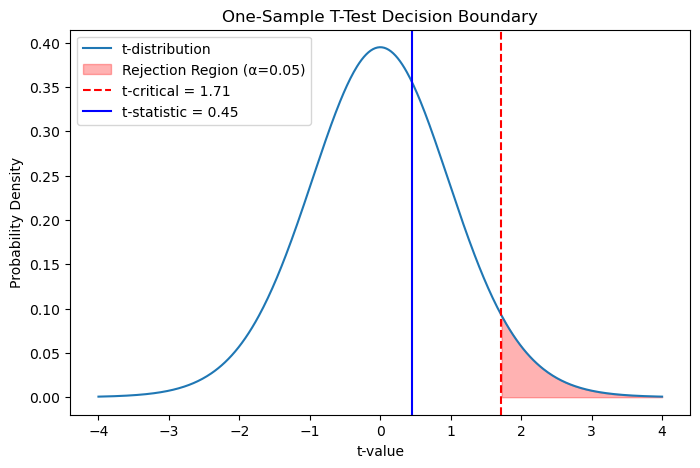

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

x = np.linspace(-4, 4, 500)               # Range of t-values
y = t.pdf(x, dfree)                        # PDF of t-distribution

plt.figure(figsize=(8, 5))
plt.plot(x, y, label="t-distribution")

# Shade rejection region
plt.fill_between(x, 0, y, where=(x > t_crit), color="red", alpha=0.3, label="Rejection Region (α=0.05)")

# Plot critical line
plt.axvline(t_crit, color="red", linestyle="--", label=f"t-critical = {t_crit:.2f}")

# Plot computed t-statistic
plt.axvline(t_test, color="blue", linestyle="-", label=f"t-statistic = {t_test:.2f}")

plt.title("One-Sample T-Test Decision Boundary")
plt.xlabel("t-value")
plt.ylabel("Probability Density")
plt.legend()
plt.show()
